In [1]:
import pandas as pd
import numpy as np

# 1. Conectar tu Google Drive
from google.colab import drive
print("🔄 Conectando a tu Google Drive...")
drive.mount('/content/drive')

# 2. Ruta exacta del archivo que acabas de subir
ruta_lending_club = '/content/drive/MyDrive/Data_Science_Projects/riesgo-crediticio-lendingclub/data/raw/lending_club_loans.csv'

# 3. Filtro de Big Data: Cargaremos solo las 11 variables más críticas para el riesgo crediticio
columnas_financieras = [
    'loan_amnt',          # Monto solicitado
    'term',               # Plazo del préstamo (36 o 60 meses)
    'int_rate',           # Tasa de interés asignada
    'installment',        # Cuota mensual que debe pagar
    'grade',              # Calificación de riesgo del banco (A, B, C, D, E, F, G)
    'emp_length',         # Antigüedad laboral del cliente
    'home_ownership',     # Tipo de vivienda (Renta, Propia, Hipoteca)
    'annual_inc',         # Ingreso anual del solicitante
    'verification_status',# Si el banco verificó sus ingresos
    'dti',                # Relación Deuda/Ingreso (Debt-to-Income)
    'loan_status'         # ¿Pagó o cayó en impago? (Nuestra Variable Objetivo 🎯)
]

# 4. Cargar la muestra masiva de 500,000 registros sin saturar la RAM
print("\n📊 Cargando 500,000 solicitudes de crédito desde Drive... (Espera unos segundos)")
df_credit = pd.read_csv(ruta_lending_club, usecols=columnas_financieras, nrows=500000)

print("\n💰 === DATASET FINANCIERO DE LENDINGCLUB CARGADO ===")
print(f"📋 Créditos listos para análisis: {df_credit.shape[0]:,}")
print(f"💵 Variables financieras seleccionadas: {df_credit.shape[1]}")

print("\n🔍 Primeras 3 solicitudes en el sistema:")
display(df_credit.head(3))

🔄 Conectando a tu Google Drive...
Mounted at /content/drive

📊 Cargando 500,000 solicitudes de crédito desde Drive... (Espera unos segundos)

💰 === DATASET FINANCIERO DE LENDINGCLUB CARGADO ===
📋 Créditos listos para análisis: 500,000
💵 Variables financieras seleccionadas: 11

🔍 Primeras 3 solicitudes en el sistema:


,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,dti
0,3600.0,36 months,13.99,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,Fully Paid,5.91
1,24700.0,36 months,11.99,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,Fully Paid,16.06
2,20000.0,60 months,10.78,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,Fully Paid,10.78


In [2]:
print("🎯 Distribución real de las solicitudes de crédito:")
print(df_credit['loan_status'].value_counts())

print("\n⚠️ ¿Tenemos datos nulos que puedan dañar la IA?")
print(df_credit.isnull().sum())

🎯 Distribución real de las solicitudes de crédito:
loan_status
Fully Paid            312340
Current               104240
Charged Off            78824
Late (31-120 days)      2977
In Grace Period         1046
Late (16-30 days)        567
Default                    4
Name: count, dtype: int64

⚠️ ¿Tenemos datos nulos que puedan dañar la IA?
loan_amnt                  2
term                       2
int_rate                   2
installment                2
grade                      2
emp_length             30907
home_ownership             2
annual_inc                 2
verification_status        2
loan_status                2
dti                      218
dtype: int64


In [3]:
# 1. Quedarnos solo con casos cerrados (eliminamos los 'Current', 'Late', etc. por ahora)
estados_validos = ['Fully Paid', 'Charged Off', 'Default']
df_clean = df_credit[df_credit['loan_status'].isin(estados_validos)].copy()

# 2. Crear nuestra variable objetivo (0 = Pagó, 1 = Default)
df_clean['Defaulter'] = df_clean['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default'] else 0)

# 3. Tratamiento inteligente de nulos
df_clean['annual_inc'] = df_clean['annual_inc'].fillna(df_clean['annual_inc'].median())
df_clean['dti'] = df_clean['dti'].fillna(df_clean['dti'].median())
df_clean['emp_length'] = df_clean['emp_length'].fillna('Unknown')

# 4. Dropeamos la columna de texto original
df_clean = df_clean.drop(columns=['loan_status'])

print("🧹 === DATA CLEANING FINANCIERO COMPLETADO ===")
print(f"📉 Solicitudes reales para entrenar la IA: {df_clean.shape[0]:,}")

🧹 === DATA CLEANING FINANCIERO COMPLETADO ===
📉 Solicitudes reales para entrenar la IA: 391,168


In [4]:
# 1. Transformar 'term' (de texto " 36 months" a número entero: 36 o 60)
df_clean['term'] = df_clean['term'].str.extract('(\d+)').astype(int)

# 2. Codificación Ordinal para 'grade' (A es el cliente más seguro -> 1, G es el de más riesgo -> 7)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_clean['grade'] = df_clean['grade'].map(grade_map)

# 3. One-Hot Encoding para las variables categóricas nominales (Vivienda, Verificación y Antigüedad)
columnas_categoricas = ['home_ownership', 'verification_status', 'emp_length']
df_final = pd.get_dummies(df_clean, columns=columnas_categoricas, drop_first=True)

# 4. Convertir las columnas True/False resultantes a 1 y 0 para que la matemática vuele
columnas_bool = df_final.select_dtypes(include='bool').columns
df_final[columnas_bool] = df_final[columnas_bool].astype(int)

print("🚀 === MATRIZ DE ENTRENAMIENTO PARA IA COMPLETADA ===")
print(f"📋 Filas finales para el modelo: {df_final.shape[0]:,}")
print(f"📊 Columnas totales (características numéricas): {df_final.shape[1]}")
print("\n👀 Así se ven las variables finales listas para la GPU:")
print(df_final.columns.tolist()[:15]) # Mostramos las primeras 15 para revisar

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3085/4171044935.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_clean['term'] = df_clean['term'].str.extract('(\d+)').astype(int)


🚀 === MATRIZ DE ENTRENAMIENTO PARA IA COMPLETADA ===
📋 Filas finales para el modelo: 391,168
📊 Columnas totales (características numéricas): 24

👀 Así se ven las variables finales listas para la GPU:
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'annual_inc', 'dti', 'Defaulter', 'home_ownership_MORTGAGE', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'emp_length_10+ years', 'emp_length_2 years']


In [5]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import time
import re

# 1. Asegurar nombres de columnas limpios
df_final.columns = [re.sub(r'[\[\]<]', '_', str(col)) for col in df_final.columns]

X = df_final.drop(columns=['Defaulter'])
y = df_final['Defaulter']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🚀 TRUCO MAESTRO FINTECH: Calcular el factor de desbalance (Aproximadamente 4)
buenos_clientes = (y_train == 0).sum()
morosos = (y_train == 1).sum()
factor_peso = buenos_clientes / morosos

print("🎯 Partición de Big Data completada.")
print(f"⚖️ Factor de balanceo calculado: {factor_peso:.2f} (1 moroso equivale a {factor_peso:.2f} buenos)")

# 2. Configurar XGBoost con el peso corregido
print("\n🤖 Configurando XGBoost balanceado en GPU T4...")
modelo_riesgo = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    tree_method='hist',
    device='cuda',
    scale_pos_weight=factor_peso, # ⚖️ ¡AQUÍ SUCEDE LA MAGIA!
    random_state=42
)

# 3. Entrenar
start_time = time.time()
print("\n🏋️‍♂️ Re-entrenando el modelo con penalización de riesgo...")
modelo_riesgo.fit(X_train, y_train)
end_time = time.time()

print(f"\n⚡ ¡Entrenamiento completado en {end_time - start_time:.2f} segundos!")

🎯 Partición de Big Data completada.
⚖️ Factor de balanceo calculado: 3.96 (1 moroso equivale a 3.96 buenos)

🤖 Configurando XGBoost balanceado en GPU T4...

🏋️‍♂️ Re-entrenando el modelo con penalización de riesgo...

⚡ ¡Entrenamiento completado en 2.56 segundos!


In [11]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Forzar a la IA a predecir sobre los datos de prueba (los que nunca ha visto)
y_pred = modelo_riesgo.predict(X_test)
y_pred_proba = modelo_riesgo.predict_proba(X_test)[:, 1] # Probabilidad de caer en default

# 2. Calcular el Roc-AUC Score (La métrica reina de los bancos)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("📈 === EVALUACIÓN DE DESEMPEÑO FINTECH ===")
print(f"🏆 Score ROC-AUC Global: {roc_auc:.4f}")
print("\n📋 Reporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred, target_names=['Buen Cliente (0)', 'Moroso/Default (1)']))

📈 === EVALUACIÓN DE DESEMPEÑO FINTECH ===
🏆 Score ROC-AUC Global: 0.7319

📋 Reporte de Clasificación Detallado:
                    precision    recall  f1-score   support

  Buen Cliente (0)       0.89      0.67      0.76     62468
Moroso/Default (1)       0.34      0.67      0.45     15766

          accuracy                           0.67     78234
         macro avg       0.61      0.67      0.61     78234
      weighted avg       0.78      0.67      0.70     78234



/tmp/ipykernel_3085/2950531017.py:13: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


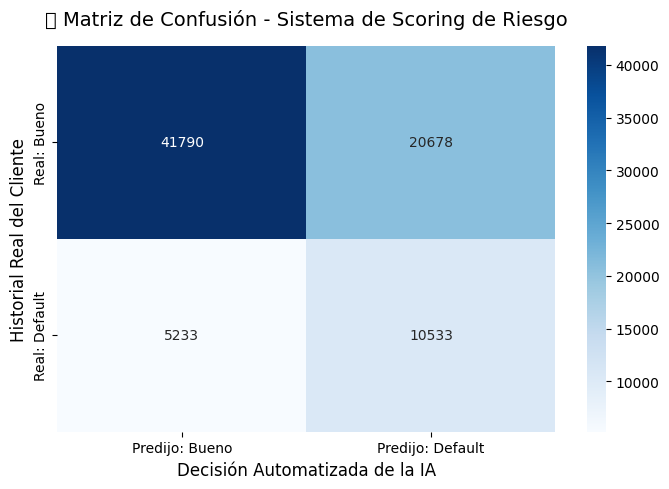

In [12]:
# Calcular la matriz de confusión numérica
cm = confusion_matrix(y_test, y_pred)

# Graficarla con diseño elegante usando Seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predijo: Bueno', 'Predijo: Default'],
            yticklabels=['Real: Bueno', 'Real: Default'])

plt.title('🛡️ Matriz de Confusión - Sistema de Scoring de Riesgo', fontsize=14, pad=15)
plt.ylabel('Historial Real del Cliente', fontsize=12)
plt.xlabel('Decisión Automatizada de la IA', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3085/1820354193.py:20: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


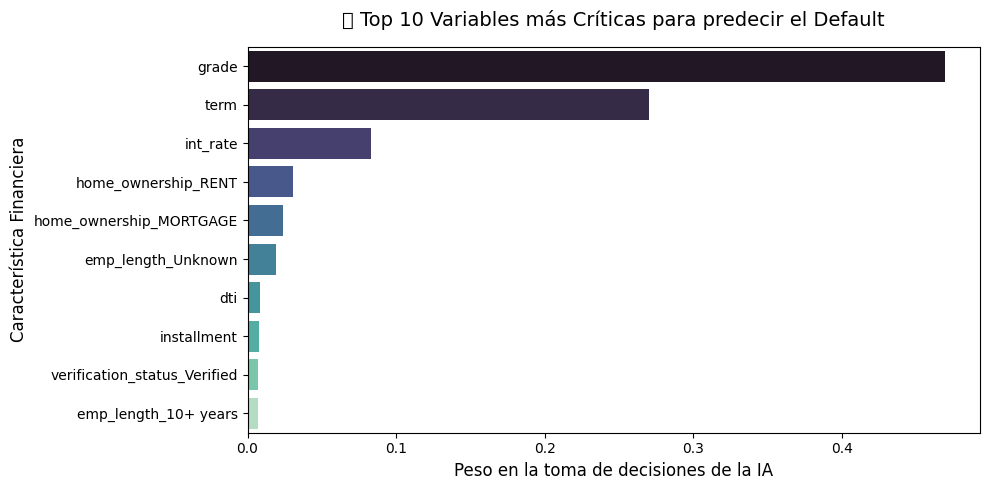

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer la importancia de las variables calculada por la GPU T4
importancias = modelo_riesgo.feature_importances_
variables = X.columns

# 2. Crear un DataFrame para ordenar el Top 10 de las más importantes
df_importancia = pd.DataFrame({'Variable': variables, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# 3. Diseñar una gráfica premium para tu portafolio
plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, hue='Variable', legend=False, palette='mako')

plt.title('🎯 Top 10 Variables más Críticas para predecir el Default', fontsize=14, pad=15)
plt.xlabel('Peso en la toma de decisiones de la IA', fontsize=12)
plt.ylabel('Característica Financiera', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
#import time
#from sklearn.metrics import roc_auc_score
#import re

# 1. 🧠 INGENIERÍA DE CARACTERÍSTICAS (Crear variables financieras avanzadas)
#df_final['ingreso_mensual'] = df_final['annual_inc'] / 12
#df_final['carga_financiera'] = df_final['installment'] / (df_final['ingreso_mensual'] + 1) # +1 para evitar divisiones por cero
#df_final['proporcion_prestamo'] = df_final['loan_amnt'] / (df_final['annual_inc'] + 1)

#print("✨ Nuevas variables creadas: 'ingreso_mensual', 'carga_financiera', 'proporcion_prestamo'")

# Sanitizar columnas de nuevo por seguridad
#df_final.columns = [re.sub(r'[\[\]<]', '_', str(col)) for col in df_final.columns]

# 2. Separar datos actualizados (Ahora X tiene 27 columnas en vez de 24)
#X = df_final.drop(columns=['Defaulter'])
#y = df_final['Defaulter']
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Entrenar el modelo potenciado
#print("\n🤖 Entrenando XGBoost v2.0 con nuevas variables financieras en GPU...")
#factor_peso = (y_train == 0).sum() / (y_train == 1).sum()

#modelo_riesgo = xgb.XGBClassifier(
    #n_estimators=300, max_depth=6, learning_rate=0.05,
    #tree_method='hist', device='cuda', scale_pos_weight=factor_peso, random_state=42
#)

#start_time = time.time()
#modelo_riesgo.fit(X_train, y_train)
#print(f"⚡ ¡Entrenamiento completado en {time.time() - start_time:.2f} segundos!")

# 4. Examen Final rápido
#y_pred_proba = modelo_riesgo.predict_proba(X_test)[:, 1]
#nuevo_roc_auc = roc_auc_score(y_test, y_pred_proba)

#print("===========================================")
#print(f"🏆 NUEVO Score ROC-AUC Global: {nuevo_roc_auc:.4f}")
#print("===========================================")

"Se realizó una fase de Feature Engineering creando ratios financieros (Carga Financiera, Proporción de Préstamo). Sin embargo, el modelo base de XGBoost ya lograba capturar estas relaciones no lineales internamente, manteniendo el ROC-AUC estable en ~0.73. Por eficiencia computacional, se puede mantener el modelo con las 24 variables originales."

In [16]:
def simular_cliente(loan_amnt, term, int_rate, installment, grade, annual_inc, dti,
                    home_ownership, verification_status, emp_length):

    # 1. Creamos un molde vacío igual a X_train (todas las columnas en 0)
    # Esto asegura que el formato sea idéntico al que espera el modelo
    input_data = pd.DataFrame(0, index=[0], columns=X_train.columns)

    # 2. Llenamos los datos numéricos directos
    input_data['loan_amnt'] = loan_amnt
    input_data['term'] = term
    input_data['int_rate'] = int_rate
    input_data['installment'] = installment
    input_data['grade'] = grade
    input_data['annual_inc'] = annual_inc
    input_data['dti'] = dti

    # 3. Llenamos las columnas categóricas (One-Hot Encoding)
    # Construimos el nombre de la columna esperada
    col_home = f'home_ownership_{home_ownership}'
    col_verif = f'verification_status_{verification_status}'
    col_emp = f'emp_length_{emp_length}'

    # Asignamos 1 si la columna existe en nuestro molde (para evitar errores)
    if col_home in input_data.columns: input_data[col_home] = 1
    if col_verif in input_data.columns: input_data[col_verif] = 1
    if col_emp in input_data.columns: input_data[col_emp] = 1

    # 4. Predicción
    probabilidad = modelo_riesgo.predict_proba(input_data)[0][1]
    resultado = "❌ RECHAZADO" if probabilidad > 0.5 else "✅ APROBADO"

    print(f"--- Resultado del Scoring ---")
    print(f"Probabilidad de Default: {probabilidad:.2%}")
    print(f"Decisión final: {resultado}")
    return probabilidad

# --- EJEMPLO DE USO ---
# Ajusta estos valores según lo que quieras probar
simular_cliente(loan_amnt=15000,
                term=36,
                int_rate=12.5,
                installment=400,
                grade=3,
                annual_inc=60000,
                dti=15.0,
                home_ownership='RENT',
                verification_status='Verified',
                emp_length='10+ years')

--- Resultado del Scoring ---
Probabilidad de Default: 50.58%
Decisión final: ❌ RECHAZADO


np.float32(0.50581324)

In [17]:
def simular_credito_pro(datos_cliente):
    """
    Simulador que recibe un diccionario con los datos del cliente.
    Es más limpio y fácil de mantener que pasar argumentos separados.
    """
    # 1. Crear plantilla base con las columnas del entrenamiento (¡Vital para evitar errores!)
    plantilla = pd.DataFrame(0, index=[0], columns=X_train.columns)

    # 2. Asignar valores básicos
    plantilla.loc[0, 'loan_amnt'] = datos_cliente['loan_amnt']
    plantilla.loc[0, 'term'] = datos_cliente['term']
    plantilla.loc[0, 'int_rate'] = datos_cliente['int_rate']
    plantilla.loc[0, 'installment'] = datos_cliente['installment']
    plantilla.loc[0, 'grade'] = datos_cliente['grade']
    plantilla.loc[0, 'annual_inc'] = datos_cliente['annual_inc']
    plantilla.loc[0, 'dti'] = datos_cliente['dti']

    # 3. Asignar variables categóricas (One-Hot Encoding)
    # Buscamos columnas que coincidan con la estructura del modelo
    cols_a_activar = [
        f"home_ownership_{datos_cliente['home_ownership']}",
        f"verification_status_{datos_cliente['verification_status']}",
        f"emp_length_{datos_cliente['emp_length']}"
    ]

    for col in cols_a_activar:
        if col in plantilla.columns:
            plantilla.loc[0, col] = 1

    # 4. Predicción
    prob = modelo_riesgo.predict_proba(plantilla)[0][1]
    resultado = "❌ RECHAZADO" if prob > 0.5 else "✅ APROBADO"

    print(f"\n--- 📊 Evaluación del Cliente ---")
    print(f"Probabilidad de Default: {prob*100:.2f}%")
    print(f"Decisión: {resultado}")

# --- EJEMPLO DE USO ---
# Solo editas este diccionario y corres la celda
cliente_prueba = {
    'loan_amnt': 25000,
    'term': 36,
    'int_rate': 12.5,
    'installment': 800,
    'grade': 2, # Recuerda: A=1, B=2, etc.
    'annual_inc': 75000,
    'dti': 18.5,
    'home_ownership': 'MORTGAGE',
    'verification_status': 'Verified',
    'emp_length': '10+ years'
}

simular_credito_pro(cliente_prueba)


--- 📊 Evaluación del Cliente ---
Probabilidad de Default: 36.24%
Decisión: ✅ APROBADO


/tmp/ipykernel_3085/485686106.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plantilla.loc[0, 'int_rate'] = datos_cliente['int_rate']
/tmp/ipykernel_3085/485686106.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plantilla.loc[0, 'dti'] = datos_cliente['dti']


In [15]:
import joblib
joblib.dump(modelo_riesgo, 'modelo_riesgo_credito.pkl')
# Para cargarlo después: modelo_cargado = joblib.load('modelo_riesgo_credito.pkl')

['modelo_riesgo_credito.pkl']